## **Support Vector Machine (SVM) Classifier**

**Support Vector Machine (SVM)** is a **supervised machine learning algorithm** used for **classification** and **regression** tasks. It is mainly used for **classification** problems because it performs well on both linear and non-linear datasets.

### How SVM Works
- SVM finds the **optimal decision boundary (hyperplane)** that separates different classes.
- It chooses the hyperplane that **maximizes the margin**, i.e., the distance between the hyperplane and the nearest data points from each class.
- The data points closest to the hyperplane are called **Support Vectors**. These points are the most important because they determine the position of the decision boundary.

### **Concepts**
- **Hyperplane:** A decision boundary that separates different classes.
- **Margin:** The distance between the hyperplane and the nearest data points.
- **Support Vectors:** The nearest data points to the hyperplane that define the optimal boundary.

### **Linear vs Non-Linear Classification**
- **Linear SVM:** Used when data is linearly separable.
- **Non-Linear SVM:** Uses the **Kernel Trick** to transform data into a higher-dimensional space where it becomes linearly separable.

### **Common Kernel Functions**
- **Linear Kernel** – For linearly separable data.
- **Polynomial Kernel** – Captures polynomial relationships.
- **RBF (Radial Basis Function) Kernel** – Most commonly used for complex, non-linear data.
- **Sigmoid Kernel** – Similar to a neural network activation function.

### **Advantages**
- Works well on **high-dimensional datasets**.
- Effective when there is a **clear margin of separation**.
- Performs well even when the number of features is greater than the number of samples.
- Can handle both **linear and non-linear** classification.

### **Disadvantages**
- Training can be slow on **large datasets**.
- Choosing the right **kernel** and hyperparameters can be challenging.
- Sensitive to noisy and overlapping data.

### **Applications**
- Email Spam Detection
- Image Classification
- Face Recognition
- Text Classification
- Medical Diagnosis
- Handwritten Digit Recognition

> **Note:** SVM aims to find the **maximum-margin hyperplane** using the **support vectors**, which helps improve the model's ability to generalize to unseen data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
plt.rcParams['figure.figsize'] = (6, 6)
%matplotlib inline

## **Part A — A Clearly Separable Dataset**

We create a synthetic 2D dataset using `make_classification`:
- `n_samples=1000`
- `n_features=2` (so we can visualize it easily)
- `n_classes=2`
- `n_clusters_per_class=1` (one tight cluster per class → easy to separate)
- `n_redundant=0` A redundant feature is one that doesn't provide new information because it's derived from other features. `n_redundant=0` means No duplicate or derived features are created.

- `n_informative=2` How many features actually contain useful information for predicting the target?

- `n_clusters_per_class=2` Each class would be split into two separate groups, making the classification problem more complex.

In [2]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000, n_features=2, n_informative=2, n_redundant=0,
    n_classes=2, n_clusters_per_class=1, random_state=41
)

df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])
df['target'] = y

df.head()


,feature_1,feature_2,target
0,1.122832,-1.008915,1
1,0.729960,-1.118407,1
2,0.092700,-0.648548,1
3,-3.200755,-0.555869,0
4,0.722615,1.857385,0


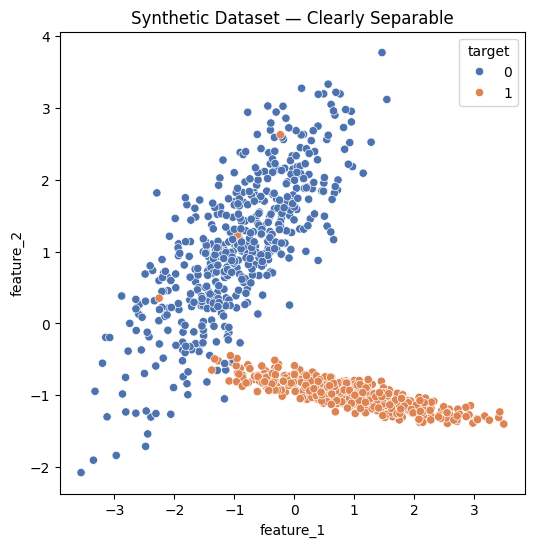

In [3]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=df['feature_1'], y=df['feature_2'], hue=df['target'], palette='deep')
plt.title('Synthetic Dataset — Clearly Separable')
plt.show()

The two classes form two clean, non-overlapping blobs — this data should be very easy for a linear boundary to separate.

## **Train/Test Split**

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=10
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (750, 2)
X_test shape : (250, 2)


## **Linear SVC on the Separable Data**

Since we can visually confirm the data is linearly separable, we use `kernel='linear'` directly (no need for a other kernel here).

In [5]:
from sklearn.svm import SVC

svc_linear = SVC(kernel='linear')
svc_linear.fit(X_train, y_train)

SVC(kernel='linear')

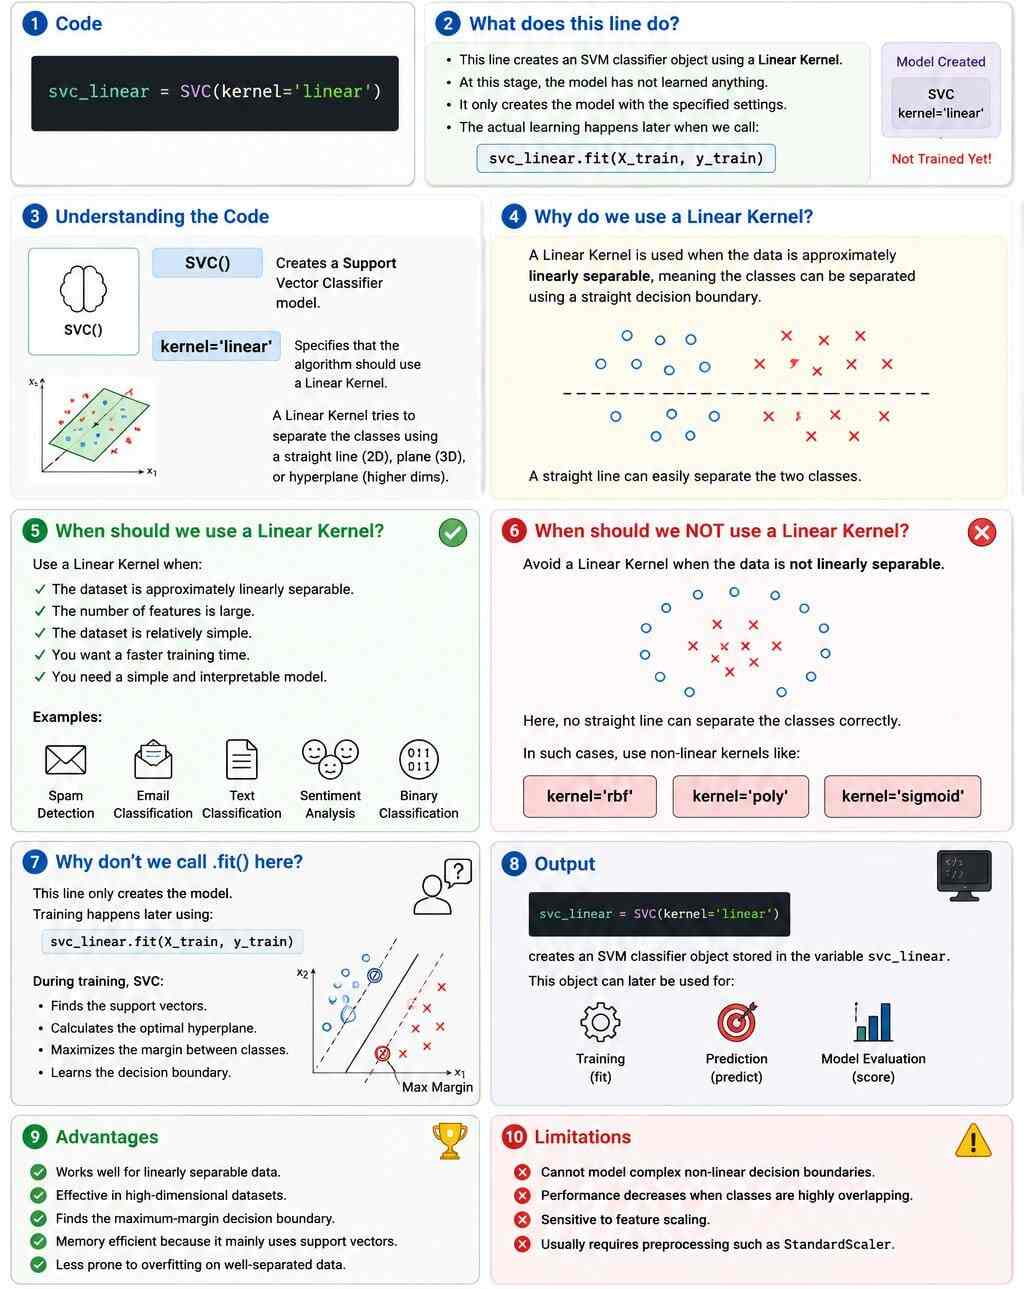

In [6]:
y_pred = svc_linear.predict(X_test)

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.984

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       123
           1       0.99      0.98      0.98       127

    accuracy                           0.98       250
   macro avg       0.98      0.98      0.98       250
weighted avg       0.98      0.98      0.98       250



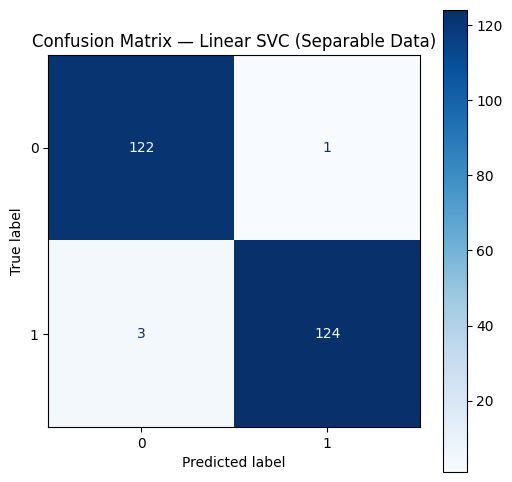

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title('Confusion Matrix — Linear SVC (Separable Data)')
plt.show()

## **Part B — A More Realistic, Overlapping Dataset**

Now let's make the problem harder and more realistic by setting `n_clusters_per_class=2`. This scatters each class into two separate clusters, causing them to **overlap** in feature space.

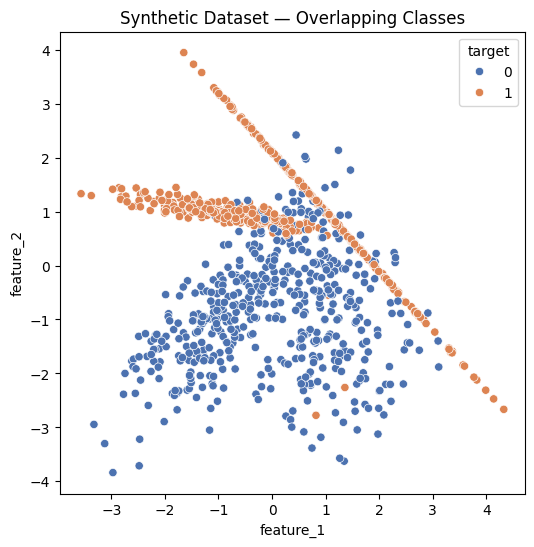

In [9]:
X2, y2 = make_classification(
    n_samples=1000, n_features=2, n_informative=2, n_redundant=0,
    n_classes=2, n_clusters_per_class=2, random_state=41
)

df2 = pd.DataFrame(X2, columns=['feature_1', 'feature_2'])
df2['target'] = y2

plt.figure(figsize=(6, 6))
sns.scatterplot(x=df2['feature_1'], y=df2['feature_2'], hue=df2['target'], palette='deep')
plt.title('Synthetic Dataset — Overlapping Classes')
plt.show()


Now the classes overlap noticeably — no single straight line will cleanly separate them anymore.


In [10]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.25, random_state=10
)

### **Linear SVC on the Overlapping Data (Expect a Drop in Accuracy)**

In [11]:
svc_linear_overlap = SVC(kernel='linear')
svc_linear_overlap.fit(X2_train, y2_train)

y_pred_linear = svc_linear_overlap.predict(X2_test)
acc_linear = accuracy_score(y2_test, y_pred_linear)
print(f"Linear SVC Accuracy (overlapping data): {acc_linear:.3f}")


Linear SVC Accuracy (overlapping data): 0.868


As expected, accuracy drops noticeably compared to Part A — a straight line simply can't capture this overlapping pattern well. Let's try other kernels.

## **RBF Kernel**

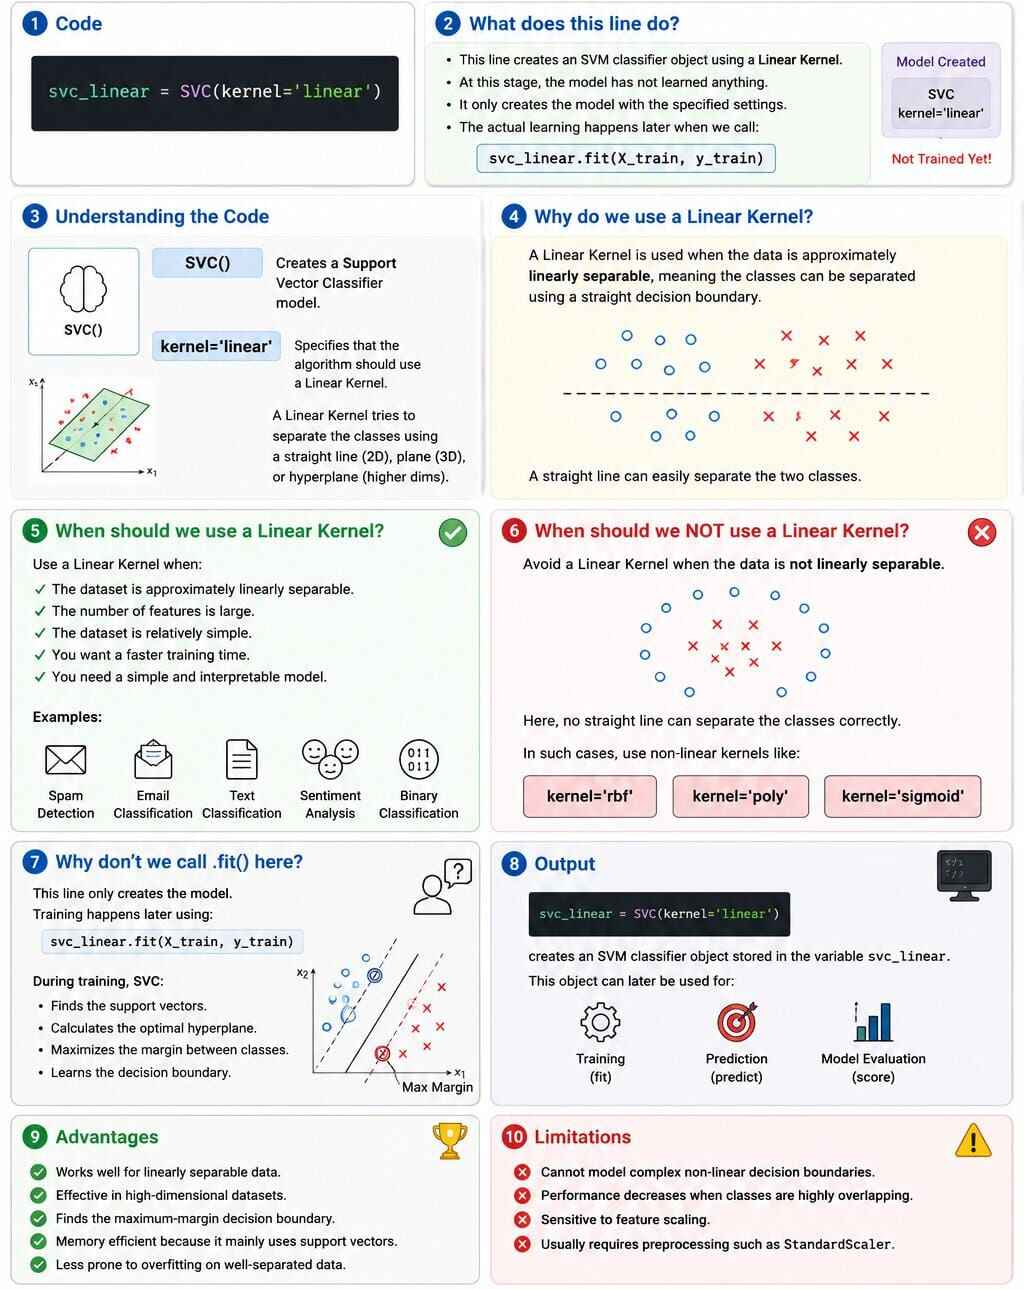

In [12]:
svc_rbf = SVC(kernel='rbf')
svc_rbf.fit(X2_train, y2_train)

y_pred_rbf = svc_rbf.predict(X2_test)
acc_rbf = accuracy_score(y2_test, y_pred_rbf)
print(f"RBF Kernel SVC Accuracy: {acc_rbf:.3f}")

RBF Kernel SVC Accuracy: 0.916


## **Polynomial Kernel**

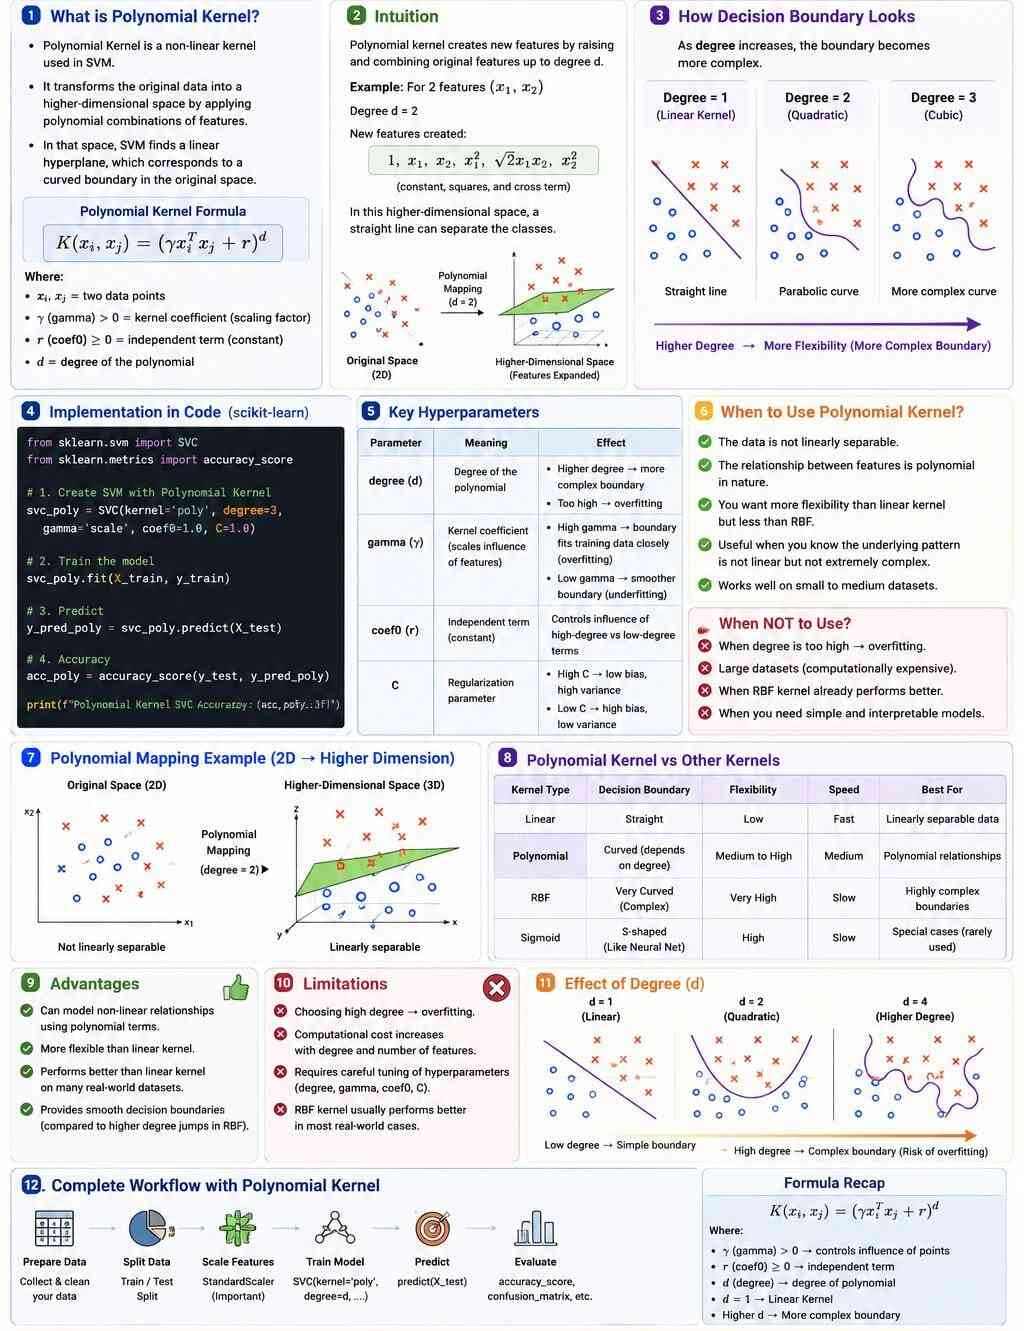

In [13]:
svc_poly = SVC(kernel='poly')
svc_poly.fit(X2_train, y2_train)

y_pred_poly = svc_poly.predict(X2_test)
acc_poly = accuracy_score(y2_test, y_pred_poly)
print(f"Polynomial Kernel SVC Accuracy: {acc_poly:.3f}")


Polynomial Kernel SVC Accuracy: 0.784


## **Sigmoid Kernel**

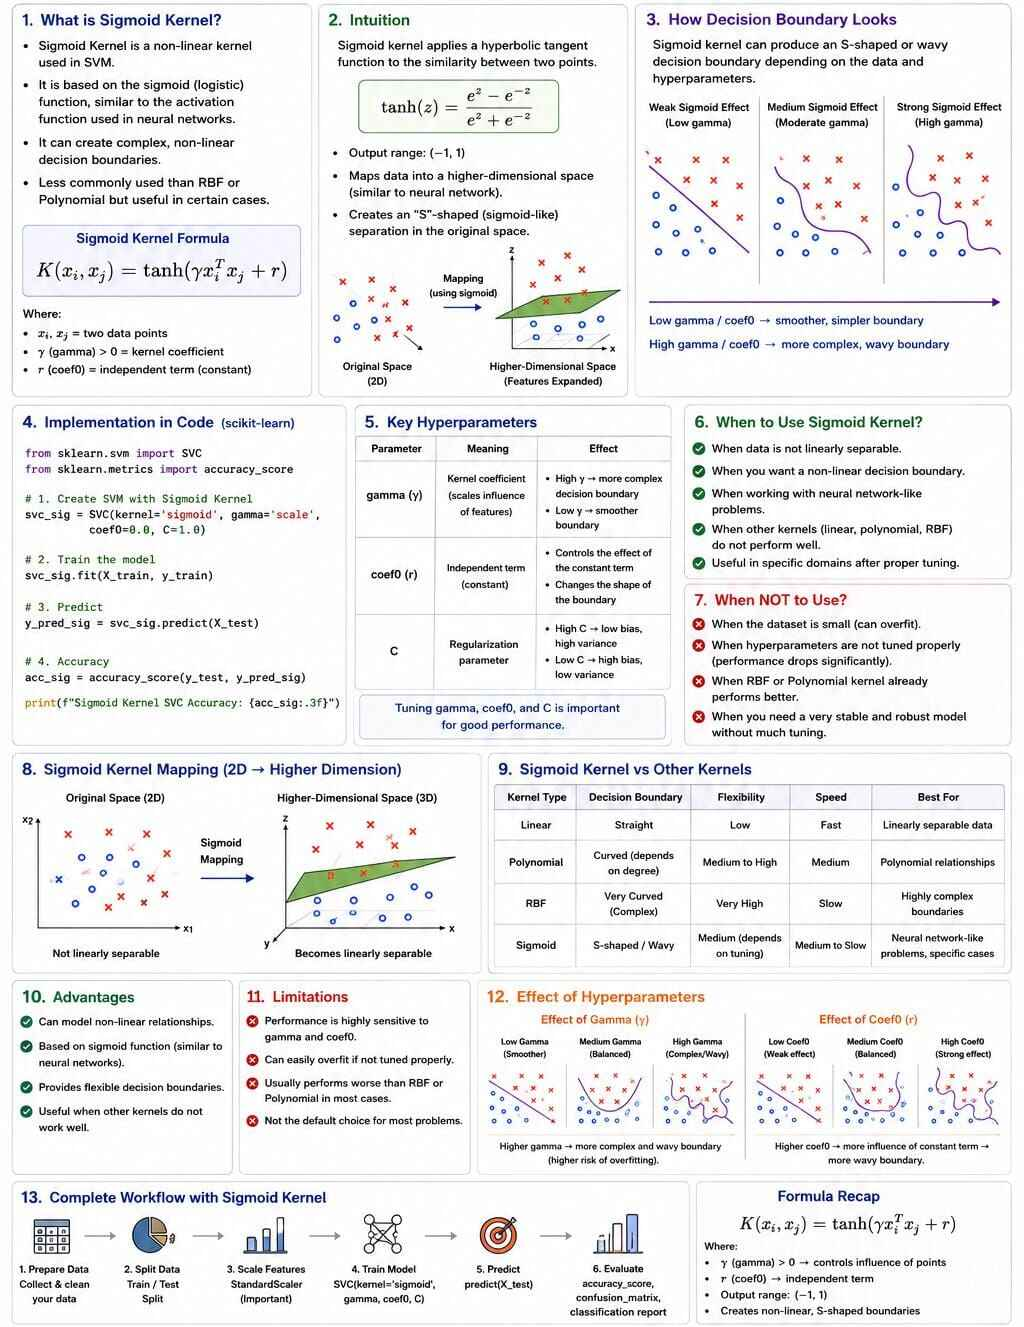

In [14]:
svc_sigmoid = SVC(kernel='sigmoid')
svc_sigmoid.fit(X2_train, y2_train)

y_pred_sigmoid = svc_sigmoid.predict(X2_test)
acc_sigmoid = accuracy_score(y2_test, y_pred_sigmoid)
print(f"Sigmoid Kernel SVC Accuracy: {acc_sigmoid:.3f}")


Sigmoid Kernel SVC Accuracy: 0.764


## **Compare All Kernels — Accuracy Table & Chart**

In [15]:
results = pd.DataFrame({
    'Kernel': ['Linear', 'RBF', 'Polynomial', 'Sigmoid'],
    'Accuracy': [acc_linear, acc_rbf, acc_poly, acc_sigmoid]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

results

,Kernel,Accuracy
0,RBF,0.916
1,Linear,0.868
2,Polynomial,0.784
3,Sigmoid,0.764


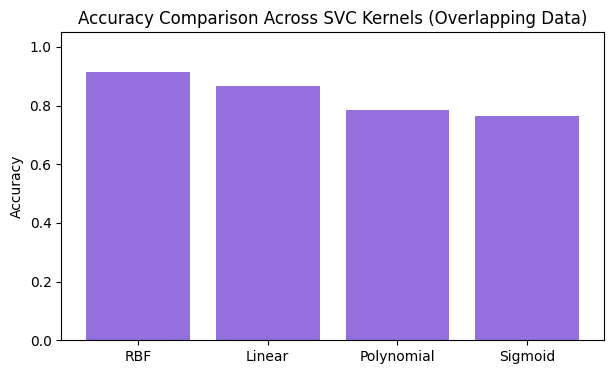

In [16]:
plt.figure(figsize=(7, 4))
plt.bar(results['Kernel'], results['Accuracy'], color='mediumpurple')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison Across SVC Kernels (Overlapping Data)')
plt.ylim(0, 1.05)
plt.show()

On this particular overlapping dataset, RBF typically comes out on top — it can bend to fit the two interleaved clusters, while poly and sigmoid tend to **underperform without careful tuning**

## **Decision Boundary Visualizations**

Accuracy numbers alone don't build intuition. Let's actually **see** the boundary each kernel draws.

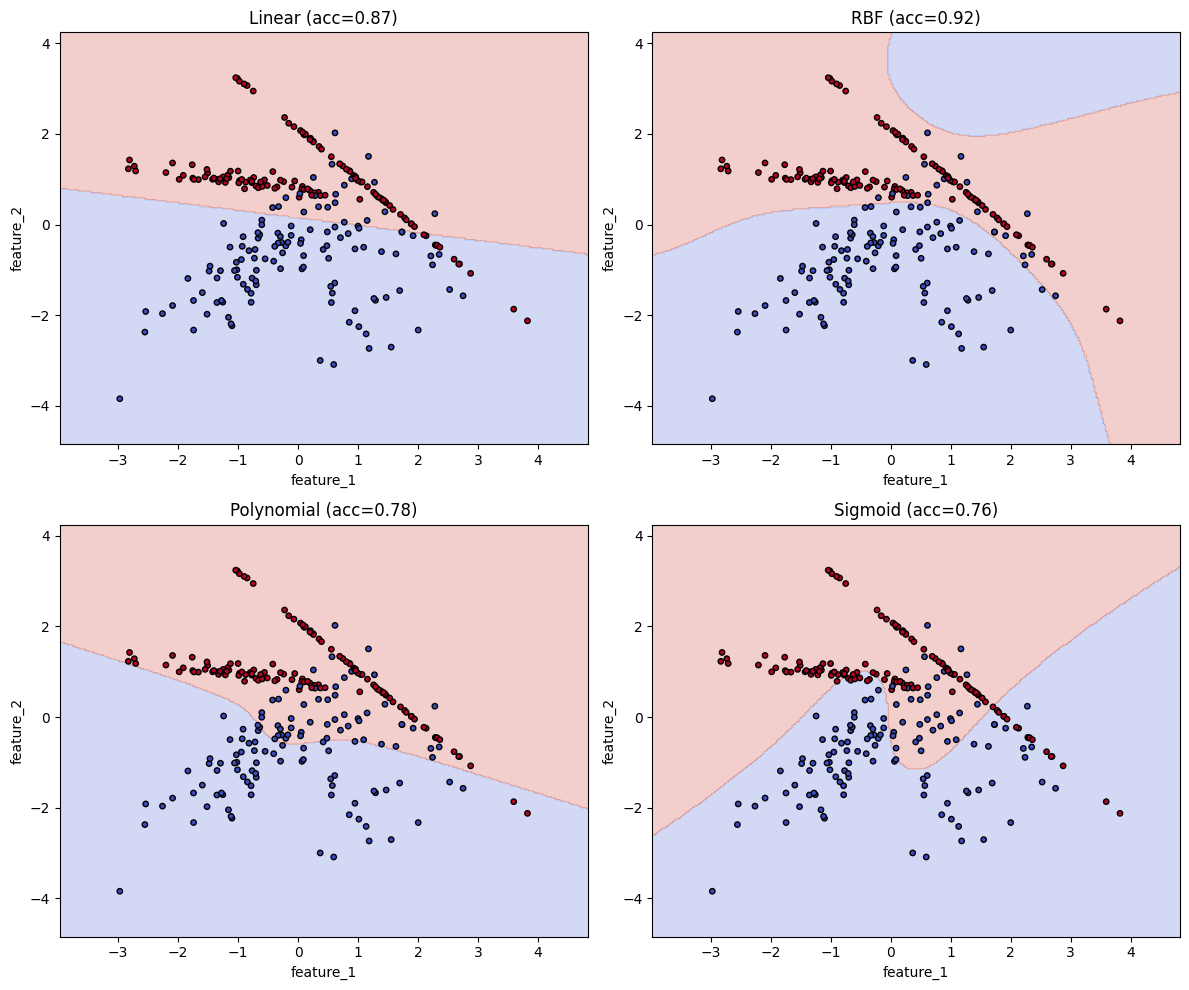

In [17]:
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=15)
    ax.set_title(title)
    ax.set_xlabel('feature_1')
    ax.set_ylabel('feature_2')


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_decision_boundary(svc_linear_overlap, X2_test, y2_test, axes[0, 0], f'Linear (acc={acc_linear:.2f})')
plot_decision_boundary(svc_rbf, X2_test, y2_test, axes[0, 1], f'RBF (acc={acc_rbf:.2f})')
plot_decision_boundary(svc_poly, X2_test, y2_test, axes[1, 0], f'Polynomial (acc={acc_poly:.2f})')
plot_decision_boundary(svc_sigmoid, X2_test, y2_test, axes[1, 1], f'Sigmoid (acc={acc_sigmoid:.2f})')

plt.tight_layout()
plt.show()

Now the accuracy differences make visual sense:
- **Linear** → one straight cut through overlapping clusters (misses a lot)
- **RBF** → smooth, curved regions that hug the actual cluster shapes
- **Polynomial / Sigmoid** → less flexible boundaries for this particular data, matching their weaker scores

## **Hyperparameter Tuning with GridSearchCV**

Since RBF performed best, we now fine-tune `C` and `gamma` for it (and let the grid confirm the best kernel choice too)

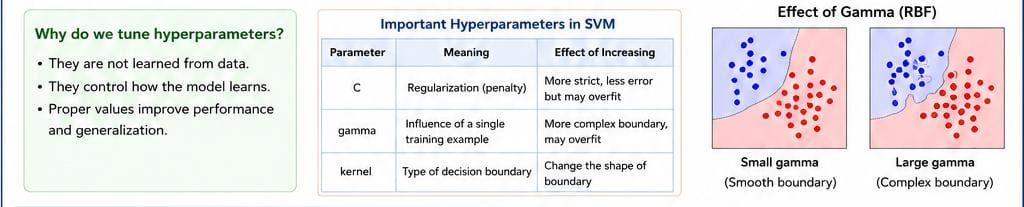

SVM has several hyperparameters such as: `C, gamma, kernel `

These values are NOT learned by the model. We must choose them before training. Instead of manually trying many combinations, GridSearchCV automatically trains and evaluates every combination using Cross Validation and selects the best one.

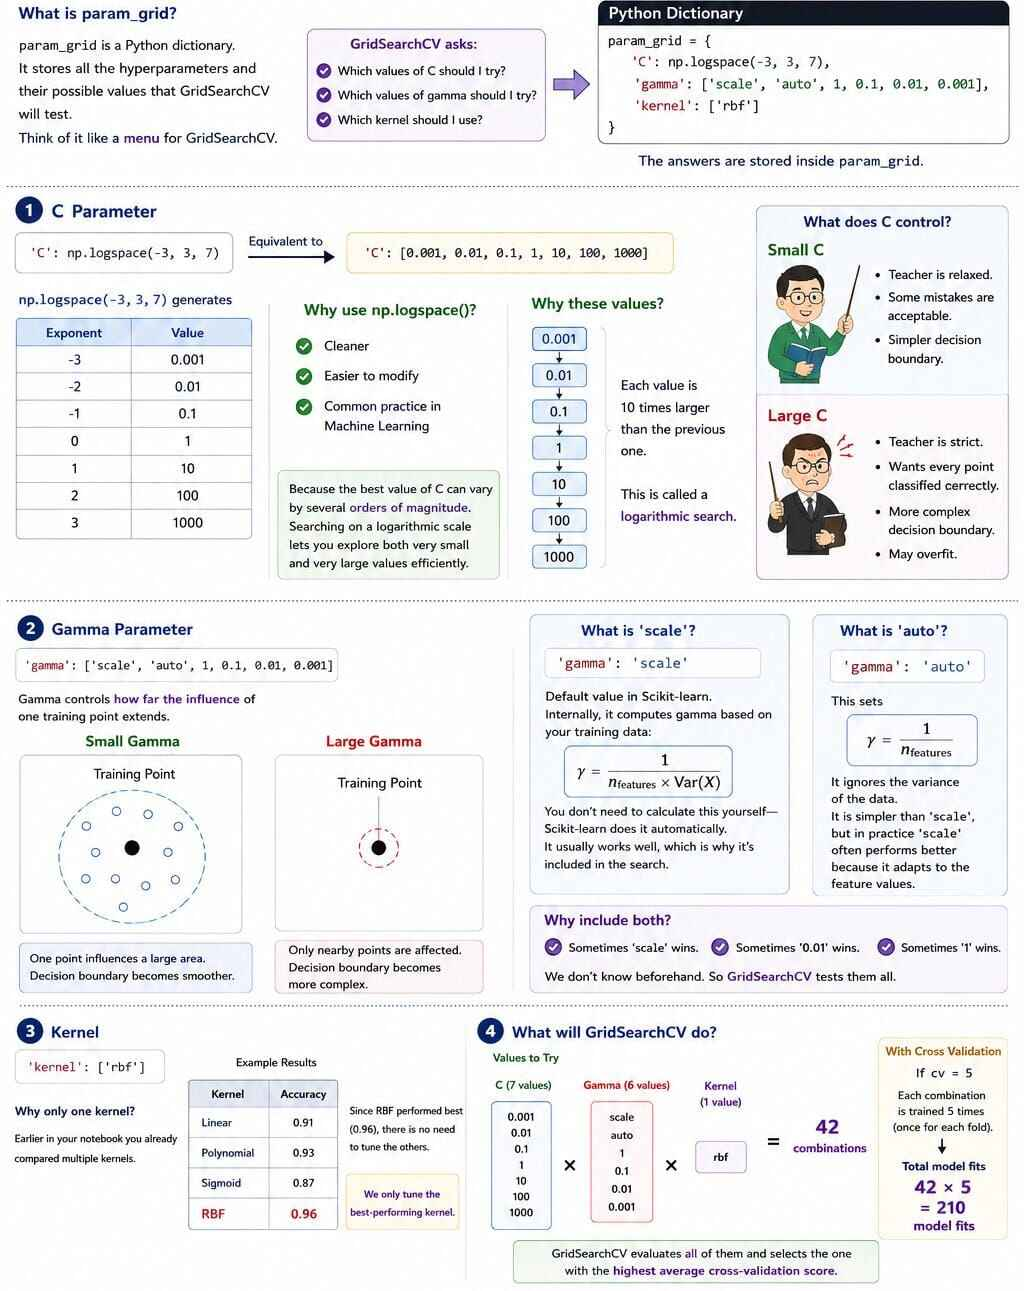

GridSearchCV performs an exhaustive search over all parameter combinations using Cross Validation and automatically selects the combination with the highest average validation score.

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {

    # Regularization parameter
    'C': np.logspace(-3, 3, 7),

    # Kernel coefficient
    'gamma': ['scale', 'auto', 1, 0.1, 0.01, 0.001],

    # Best-performing kernel selected earlier
    'kernel': ['rbf']
}

# refit=True : After finding the best parameters,retrains the model using the entire training dataset.
# verbose=1 : Displays training progress.

grid = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    cv=5,
    refit=True,
    verbose=1,
    n_jobs=-1
)

# GridSearchCV will:
# Step 1:
# Try every combination of C and gamma.

# Step 2:
# Perform 5-Fold Cross Validation for each combination.

# Step 3:
# Compute the average validation accuracy.

# Step 4:
# Select the best combination.

# Step 5:
# Retrain the model on the complete training data.
grid.fit(X2_train, y2_train)

# Best Hyperparameters

print("Best Parameters:")
print(grid.best_params_)

print()

print("Best Cross Validation Accuracy:")
print(f"{grid.best_score_:.3f}")

print()

print("Best Model:")
print(grid.best_estimator_)


Fitting 5 folds for each of 42 candidates, totalling 210 fits
Best Parameters:
{'C': np.float64(1000.0), 'gamma': 1, 'kernel': 'rbf'}

Best Cross Validation Accuracy:
0.944

Best Model:
SVC(C=np.float64(1000.0), gamma=1, random_state=42)


In [19]:
# Predict using the Best Tuned Model

# Since refit=True,
# GridSearchCV has already trained the best model.
# We simply use predict() on the unseen test data.

y_pred_grid = grid.predict(X2_test)

# Evaluate the Tuned Model
acc_tuned = accuracy_score(y2_test, y_pred_grid)

print(f"Tuned SVC Test Accuracy : {acc_tuned:.3f}")
print()
print("Classification Report")
print(classification_report(y2_test, y_pred_grid))

Tuned SVC Test Accuracy : 0.940

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.90      0.94       123
           1       0.91      0.98      0.94       127

    accuracy                           0.94       250
   macro avg       0.94      0.94      0.94       250
weighted avg       0.94      0.94      0.94       250



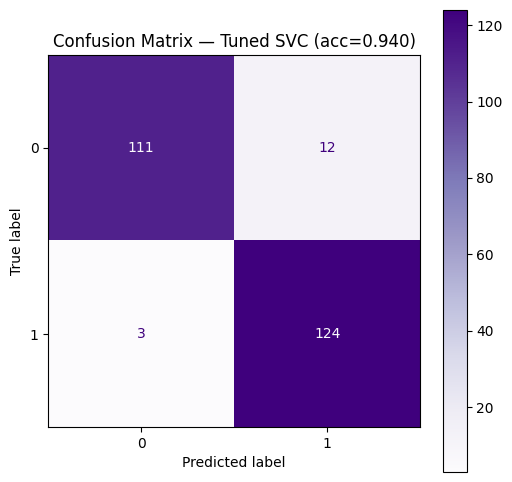

In [20]:
# Confusion Matrix
cm_tuned = confusion_matrix(y2_test, y_pred_grid)
ConfusionMatrixDisplay(cm_tuned).plot(cmap='Purples')
plt.title(f'Confusion Matrix — Tuned SVC (acc={acc_tuned:.3f})')
plt.show()

Tuning `C` and `gamma` typically improves on the untuned RBF result — exactly the "88% → 93%"-style jump the transcript demonstrates. The improvement comes purely from picking better values for how strict the margin is (`C`) and how far each point's influence reaches (`gamma`), without changing the kernel family at all.

## **Inspecting `coef_` and `intercept_`**

- `intercept_` (the bias term `b`) is available for **every** kernel.
- `coef_` (the weight vector `w`) is only available for the **linear** kernel — curved boundaries (`rbf`, `poly`, `sigmoid`) don't have a single set of linear coefficients to report.

In [21]:
# Understanding coef_ and intercept_

# Decision Boundary Equation : w·x + b = 0
# where, w -> Weight Vector (coef_) , b -> Bias (intercept_)

# Linear Kernel : A Linear SVM learns one straight decision boundary.

# Therefore,
# coef_      -> Available
# intercept_ -> Available

# RBF Kernel : RBF creates a curved (non-linear) decision boundary.
# Since there is NO single straight-line equation,
# there is NO single weight vector.

# Therefore, coef_  -> NOT Available, intercept_ -> Available

print("Linear SVC Weight Vector (coef_):")
print(svc_linear_overlap.coef_)
print()
print("Linear SVC Bias (intercept_):")
print(svc_linear_overlap.intercept_)

Linear SVC Weight Vector (coef_):
[[0.24876328 1.50379571]]

Linear SVC Bias (intercept_):
[-0.21567699]


In [22]:
try:
    print(svc_rbf.coef_)
except AttributeError as e:
    print("As expected, RBF kernel has no coef_ attribute:")
    print(e)

print("\nBut intercept_ IS available for RBF:", svc_rbf.intercept_)

As expected, RBF kernel has no coef_ attribute:
coef_ is only available when using a linear kernel

But intercept_ IS available for RBF: [-0.00159204]


## **A Note on Feature Scaling**

Just like SVR, `SVC` with `rbf`/`poly`/`sigmoid` kernels is **distance-based**, so it's sensitive to feature scale. Our synthetic features here happen to already be on similar ranges (which is why scaling didn't visibly matter above) — but on real-world data with features like "age" (0–100) and "income" (0–500,000), skipping `StandardScaler` before fitting an SVC can seriously hurt performance. As a rule of thumb: **always scale your features before SVC/SVR**, unless you've explicitly checked they're already comparable.

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X2_train_scaled = scaler.fit_transform(X2_train)
X2_test_scaled = scaler.transform(X2_test)

svc_rbf_scaled = SVC(kernel='rbf')
svc_rbf_scaled.fit(X2_train_scaled, y2_train)

y_pred_rbf_scaled = svc_rbf_scaled.predict(X2_test_scaled)
acc_rbf_scaled = accuracy_score(y2_test, y_pred_rbf_scaled)

print(f"RBF Kernel SVC Accuracy (unscaled): {acc_rbf:.3f}")
print(f"RBF Kernel SVC Accuracy (scaled)  : {acc_rbf_scaled:.3f}")

RBF Kernel SVC Accuracy (unscaled): 0.916
RBF Kernel SVC Accuracy (scaled)  : 0.916


## **Cross-Validation**

A single train-test split may produce optimistic or pessimistic results depending on how the data is divided. To obtain a more reliable estimate of the model's performance, we use **5-Fold Cross-Validation**.

In this process, the training data is split into **5 equal folds**. The model is trained **5 times**, using a different fold for validation in each iteration while the remaining folds are used for training.

Finally, the accuracy scores from all five iterations are averaged, providing a more robust evaluation of the tuned SVM model.

In [24]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(grid.best_estimator_, X2, y2, cv=5, scoring='accuracy')
print("Cross-validation accuracy scores:", np.round(cv_scores, 3))
print(f"Mean CV Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

Cross-validation accuracy scores: [0.96  0.965 0.91  0.95  0.955]
Mean CV Accuracy: 0.948 (+/- 0.020)


## **ROC Curve for the Tuned SVM Model**

Accuracy is a useful evaluation metric, but it does not always provide the complete picture of a model's performance, especially when working with imbalanced datasets.

The **Receiver Operating Characteristic (ROC) Curve** evaluates the classifier across different decision thresholds by plotting:

- **True Positive Rate (TPR)** on the Y-axis
- **False Positive Rate (FPR)** on the X-axis

The **Area Under the Curve (AUC)** summarizes the overall performance of the classifier:

- **AUC = 1.0** → Perfect classifier
- **AUC = 0.5** → Random guessing
- **Higher AUC** → Better class discrimination

Since the ROC curve requires prediction probabilities, we enable `probability=True` in the tuned SVM model and then evaluate its ROC-AUC score.

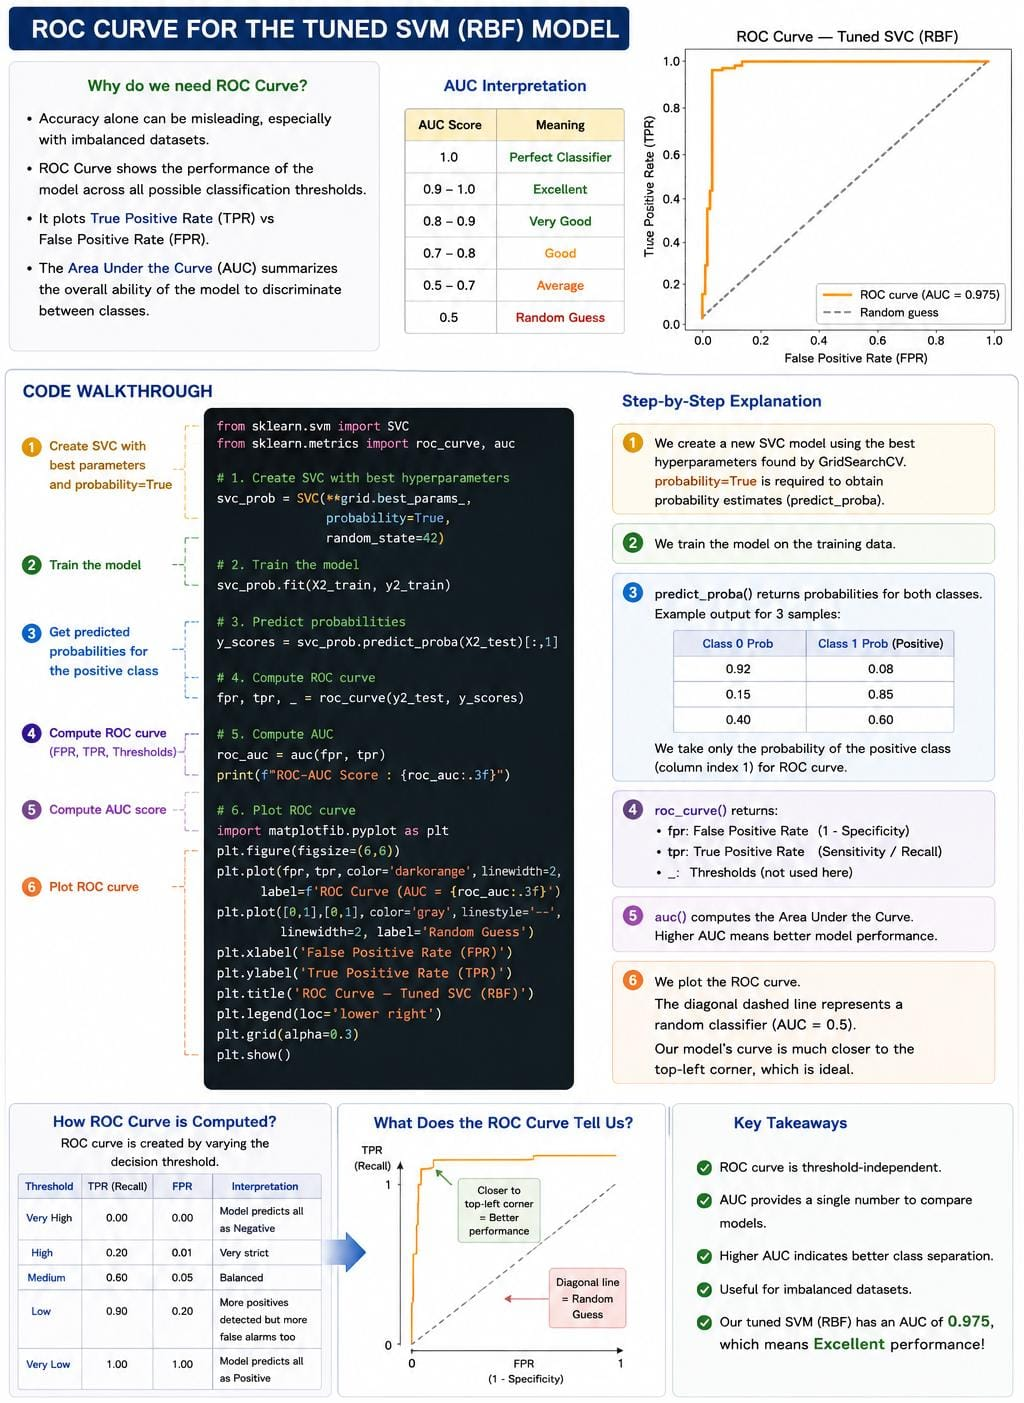

ROC-AUC is especially useful when the dataset is imbalanced because it evaluates the model across all classification thresholds instead of relying on a single accuracy value.

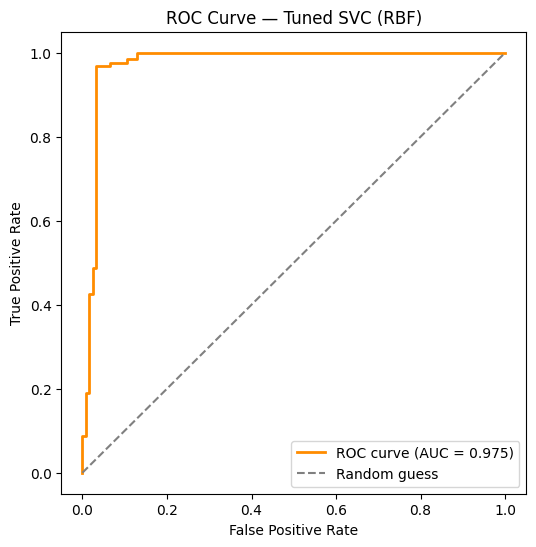

In [25]:
from sklearn.metrics import roc_curve, auc

# probability=True lets us get predicted probabilities for the ROC curve
svc_prob = SVC(**grid.best_params_, probability=True)
svc_prob.fit(X2_train, y2_train)

y_scores = svc_prob.predict_proba(X2_test)[:, 1]
fpr, tpr, _ = roc_curve(y2_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', linewidth=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Tuned SVC (RBF)')
plt.legend()
plt.show()

## **Multiclass Classification with SVC**

The transcript mentions SVM can also handle multiclass problems but never demonstrates it. `SVC` handles this automatically under the hood (using a one-vs-one strategy by default) — no special setup needed beyond passing a `y` with more than 2 classes.

In [26]:
X3, y3 = make_classification(
    n_samples=900, n_features=2, n_informative=2, n_redundant=0,
    n_classes=3, n_clusters_per_class=1, random_state=7
)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.25, random_state=10
)

svc_multiclass = SVC(kernel='rbf')
svc_multiclass.fit(X3_train, y3_train)

y3_pred = svc_multiclass.predict(X3_test)
print(f"Multiclass SVC Accuracy: {accuracy_score(y3_test, y3_pred):.3f}")
print()
print(classification_report(y3_test, y3_pred))


Multiclass SVC Accuracy: 0.929

              precision    recall  f1-score   support

           0       0.85      0.88      0.87        59
           1       1.00      0.96      0.98        85
           2       0.91      0.93      0.92        81

    accuracy                           0.93       225
   macro avg       0.92      0.92      0.92       225
weighted avg       0.93      0.93      0.93       225



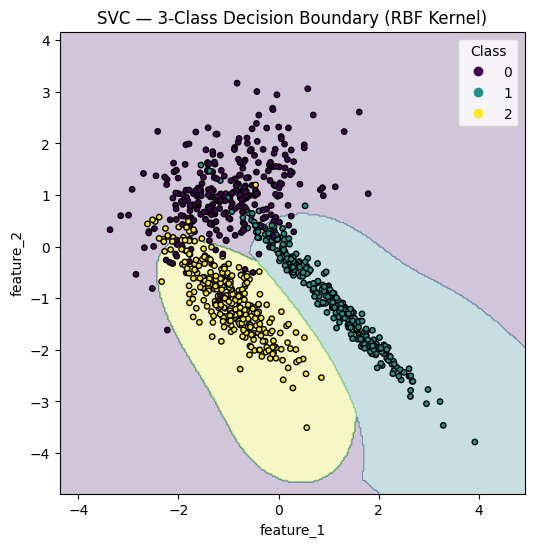

In [27]:
fig, ax = plt.subplots(figsize=(6, 6))

x_min, x_max = X3[:, 0].min() - 1, X3[:, 0].max() + 1
y_min, y_max = X3[:, 1].min() - 1, X3[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = svc_multiclass.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

ax.contourf(xx, yy, Z, alpha=0.25, cmap='viridis')
scatter = ax.scatter(X3[:, 0], X3[:, 1], c=y3, cmap='viridis', edgecolors='k', s=15)
ax.set_title('SVC — 3-Class Decision Boundary (RBF Kernel)')
ax.set_xlabel('feature_1')
ax.set_ylabel('feature_2')
plt.legend(*scatter.legend_elements(), title='Class')
plt.show()

`SVC` splits a 3-class problem into 3 binary sub-problems internally (class 0 vs 1, 0 vs 2, 1 vs 2 — "one-vs-one") and combines their votes, producing the clean 3-way decision regions shown above.


**Practical checklist for any future SVC project:**
1. Plot your data first — get a feel for whether it's linearly separable
2. Start with `linear`, only reach for `rbf`/`poly`/`sigmoid` if needed
3. Scale your features before fitting
4. Compare kernels using both accuracy **and** decision boundary plots
5. Tune with `GridSearchCV`, then validate with cross-validation
6. Check `classification_report` / confusion matrix / ROC — not accuracy alone